In [2]:
pip install pyarrow


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

# Read the CSV file into a DataFrame
df = pd.read_csv("D:\\House_1.csv")

# Convert the DataFrame to a Parquet file



In [2]:




# Convert 'Time' column to datetime format
df['Time'] = pd.to_datetime(df['Time'])

# Set 'Time' as the index (required for resampling)
df.set_index('Time', inplace=True)

# Resample with a 20-second interval and sum the values in each interval
# You can change '20S' to other time frequencies as needed
df_resampled = df.resample('20S').sum()

# Reset the index to make 'Time' a regular column again
df_resampled.reset_index(inplace=True)

# Overwrite the original CSV file with the resampled data
df_resampled.to_csv("D:\\House_1.csv", index=False)

# Display the resampled DataFrame
print(df_resampled.head())


PermissionError: [Errno 13] Permission denied: 'D:\\House_1.csv'

In [4]:
print(df_resampled.head())

                 Time        Unix  Aggregate  Appliance1  Appliance2  \
0 2013-10-09 13:06:00  1381323977        523          74           0   
1 2013-10-09 13:06:20  1381323991        526          75           0   
2 2013-10-09 13:06:40  1381324006        540          74           0   
3 2013-10-09 13:07:00  4143972094       1611         222           0   
4 2013-10-09 13:07:20  2762648102       1074         148           0   

   Appliance3  Appliance4  Appliance5  Appliance6  Appliance7  Appliance8  \
0          69           0           0           0           0           0   
1          69           0           0           0           0           0   
2          68           0           0           0           0           0   
3         206           0           0           0           0           0   
4         138           0           0           0           0           0   

   Appliance9  
0           1  
1           1  
2           1  
3           3  
4           2  


D:\conda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


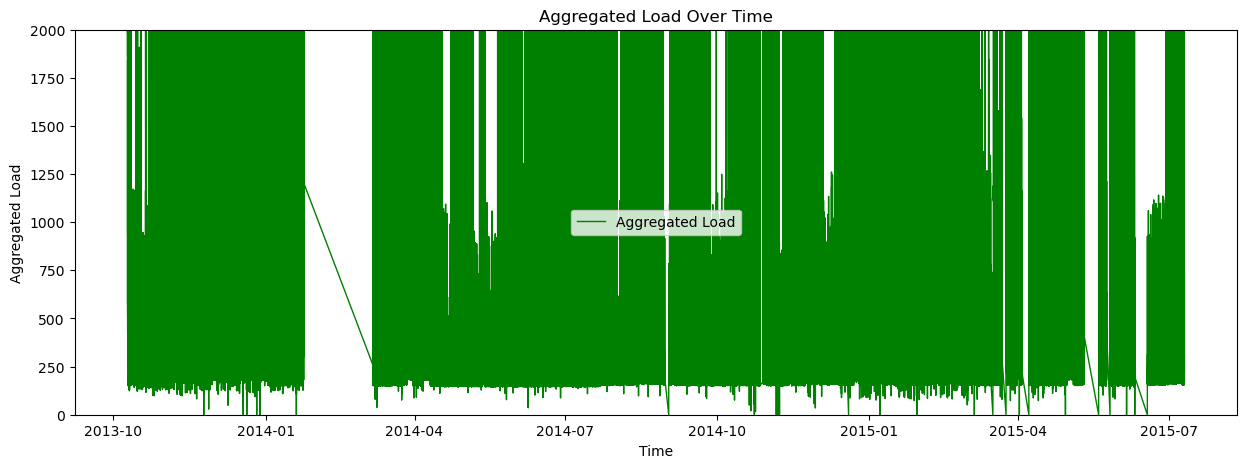

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Aggregate'], label='Aggregated Load', color='green', linewidth=1)

# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Aggregated Load')
plt.title('Aggregated Load Over Time')
plt.legend()
plt.show()


ADF Statistic for window 0-5000: -6.800449441772205
p-value: 2.244104179586676e-09
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 5000-10000: -8.726028516359586
p-value: 3.28688422204508e-14
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 10000-15000: -6.2045393633326125
p-value: 5.6999022462080944e-08
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 15000-20000: -3.9351920409188264
p-value: 0.001790588908098277
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 20000-25000: -5.174317495333353
p-value: 9.917995907645146e-06
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 25000-30000: -5.269259939117441
p-value: 6.338285121104857e-06
The time series is likely stationary (reject the null hypothesis)
ADF Statistic for window 30000-35000: -5.5478676799764575
p-value: 1.645157841548

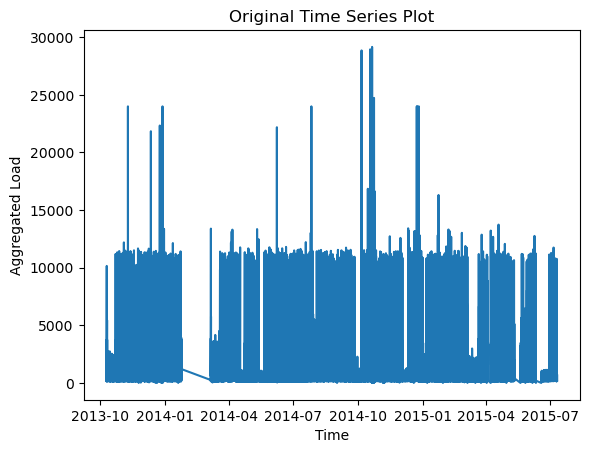

In [6]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

# Assuming your DataFrame is named 'df' and 'Timestamp' is the datetime column
# Replace 'Aggregate' with the actual column name you're interested in
time_series = df['Aggregate']

# Specify the rolling window size
window_size = 5000

# Iterate through the time series with a rolling window and perform ADF test
for i in range(0, len(time_series), window_size):
    windowed_series = time_series[i:i+window_size]
    result = adfuller(windowed_series, autolag='AIC')
    
    # Extract ADF test statistics and p-value
    adf_stat = result[0]
    p_value = result[1]

    # Print the results
    print(f'ADF Statistic for window {i}-{i+window_size}: {adf_stat}')
    print(f'p-value: {p_value}')

    # Check for significance
    if p_value <= 0.05:
        print('The time series is likely stationary (reject the null hypothesis)')
    else:
        print('The time series is likely non-stationary (fail to reject the null hypothesis)')

# Plot the original time series
plt.plot(df.index, time_series)
plt.xlabel('Time')
plt.ylabel('Aggregated Load')
plt.title('Original Time Series Plot')
plt.show()


In [10]:
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Assuming you have a DataFrame named 'df'

# Perform clustering with explicit n_init
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[['Aggregate','Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']])

# Iterate through clusters and fit linear regression models
for cluster in df['cluster'].unique():
    print(f"\nCluster {cluster}:")

    # Extract data for the current cluster
    cluster_data = df[df['cluster'] == cluster]
    
    # Display some information about the cluster data
    print(cluster_data.head())

    # Check if 'target' column exists in cluster_data
    if 'Aggregate' in cluster_data.columns:
        X = cluster_data[['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']]
        y = cluster_data['Aggregate']

        # Initialize and fit the linear regression model
        model = LinearRegression()
        model.fit(X, y)

        # Predict values for the same features
        predicted_values = model.predict(X)

        # Add the predicted values to the cluster_data DataFrame
        for i, appliance in enumerate(['Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']):
            cluster_data[f'Predicted_{appliance}'] = predicted_values

        # Display the updated cluster_data with predicted values
        print(cluster_data[['Predicted_Appliance1', 'Predicted_Appliance2', 'Predicted_Appliance3', 'Predicted_Appliance4', 'Predicted_Appliance5', 'Predicted_Appliance6', 'Predicted_Appliance7', 'Predicted_Appliance8', 'Predicted_Appliance9']])
        
    else:
        print("'target' column not found in the cluster_data.")



Cluster 0:
                           Unix  Aggregate  Appliance1  Appliance2  \
Time                                                                 
2013-10-09 13:06:17  1381323977        523          74           0   
2013-10-09 13:06:31  1381323991        526          75           0   
2013-10-09 13:06:46  1381324006        540          74           0   
2013-10-09 13:07:01  1381324021        532          74           0   
2013-10-09 13:07:15  1381324035        540          74           0   

                     Appliance3  Appliance4  Appliance5  Appliance6  \
Time                                                                  
2013-10-09 13:06:17          69           0           0           0   
2013-10-09 13:06:31          69           0           0           0   
2013-10-09 13:06:46          68           0           0           0   
2013-10-09 13:07:01          68           0           0           0   
2013-10-09 13:07:15          69           0           0           0   


C:\Users\anand\AppData\Local\Temp\ipykernel_36476\2223110782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_36476\2223110782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_36476\2223110782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

                     Predicted_Appliance1  Predicted_Appliance2  \
Time                                                              
2013-10-09 13:06:17            310.751914            310.751914   
2013-10-09 13:06:31            311.180139            311.180139   
2013-10-09 13:06:46            310.142397            310.142397   
2013-10-09 13:07:01            310.142397            310.142397   
2013-10-09 13:07:15            310.751914            310.751914   
...                                   ...                   ...   
2015-07-10 11:56:05            250.236285            250.236285   
2015-07-10 11:56:12            250.236285            250.236285   
2015-07-10 11:56:18            250.236285            250.236285   
2015-07-10 11:56:25            250.236285            250.236285   
2015-07-10 11:56:32            250.236285            250.236285   

                     Predicted_Appliance3  Predicted_Appliance4  \
Time                                                         

C:\Users\anand\AppData\Local\Temp\ipykernel_36476\2223110782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_36476\2223110782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_data[f'Predicted_{appliance}'] = predicted_values
C:\Users\anand\AppData\Local\Temp\ipykernel_36476\2223110782.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usin

In [12]:
print(cluster_data.columns)


Index(['Unix', 'Aggregate', 'Appliance1', 'Appliance2', 'Appliance3',
       'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8',
       'Appliance9', 'cluster', 'Predicted_Appliance1', 'Predicted_Appliance2',
       'Predicted_Appliance3', 'Predicted_Appliance4', 'Predicted_Appliance5',
       'Predicted_Appliance6', 'Predicted_Appliance7', 'Predicted_Appliance8',
       'Predicted_Appliance9'],
      dtype='object')


In [13]:
import pandas as pd

# Assuming you have a DataFrame named 'df' with columns 'Aggregate', 'Appliance1', ..., 'Appliance9'
# Replace 'YourDataFrame' and 'YourColumns' with the actual names in your dataset
columns_to_difference = ['Aggregate', 'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5', 'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9']

# Apply differencing to each column
df_differenced = df[columns_to_difference].diff().dropna()

# Display the differenced DataFrame
print(df_differenced.head())


                     Aggregate  Appliance1  Appliance2  Appliance3  \
Time                                                                 
2013-10-09 13:06:31        3.0         1.0         0.0         0.0   
2013-10-09 13:06:46       14.0        -1.0         0.0        -1.0   
2013-10-09 13:07:01       -8.0         0.0         0.0         0.0   
2013-10-09 13:07:15        8.0         0.0         0.0         1.0   
2013-10-09 13:07:18       -1.0         0.0         0.0         0.0   

                     Appliance4  Appliance5  Appliance6  Appliance7  \
Time                                                                  
2013-10-09 13:06:31         0.0         0.0         0.0         0.0   
2013-10-09 13:06:46         0.0         0.0         0.0         0.0   
2013-10-09 13:07:01         0.0         0.0         0.0         0.0   
2013-10-09 13:07:15         0.0         0.0         0.0         0.0   
2013-10-09 13:07:18         0.0         0.0         0.0         0.0   

           

In [55]:
from statsmodels.tsa.stattools import adfuller

# Assuming you have a DataFrame named 'df_differenced'
# Replace 'YourDataFrame' with the actual name in your dataset

# Specify the chunk size
chunk_size = 10000

# Get the number of chunks needed
num_chunks = len(df_differenced) // chunk_size + 1

# Perform ADF test for each chunk
for i in range(num_chunks):
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(df_differenced))
    
    result = adfuller(df_differenced['Aggregate'].iloc[start_idx:end_idx], autolag='AIC')

    # Extract and print the p-value
    p_value = result[1]
    print(f'ADF Test p-value for chunk {i+1}: {p_value}')

    # Check the p-value against the significance level (e.g., 0.05)
    if p_value <= 0.05:
        print(f'The time series data in chunk {i+1} is likely stationary.')
    else:
        print(f'The time series data in chunk {i+1} is likely non-stationary.')


ADF Test p-value for chunk 1: 0.0
The time series data in chunk 1 is likely stationary.
ADF Test p-value for chunk 2: 0.0
The time series data in chunk 2 is likely stationary.
ADF Test p-value for chunk 3: 0.0
The time series data in chunk 3 is likely stationary.
ADF Test p-value for chunk 4: 0.0
The time series data in chunk 4 is likely stationary.
ADF Test p-value for chunk 5: 0.0
The time series data in chunk 5 is likely stationary.
ADF Test p-value for chunk 6: 0.0
The time series data in chunk 6 is likely stationary.
ADF Test p-value for chunk 7: 6.355997998203654e-29
The time series data in chunk 7 is likely stationary.
ADF Test p-value for chunk 8: 0.0
The time series data in chunk 8 is likely stationary.
ADF Test p-value for chunk 9: 5.073057226653944e-30
The time series data in chunk 9 is likely stationary.
ADF Test p-value for chunk 10: 0.0
The time series data in chunk 10 is likely stationary.
ADF Test p-value for chunk 11: 0.0
The time series data in chunk 11 is likely stat

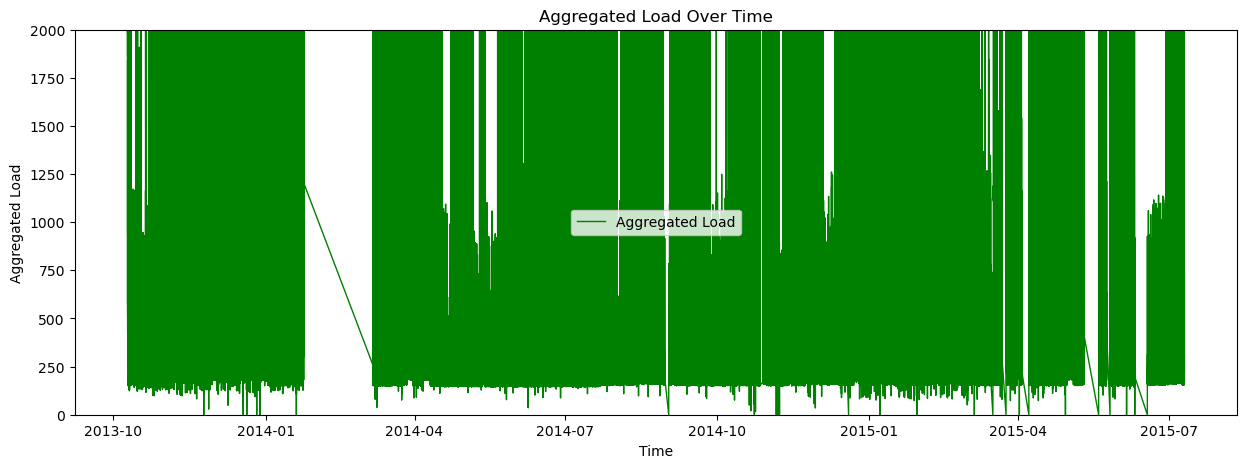

In [57]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Aggregate'], label='Aggregated Load', color='green', linewidth=1)

# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Aggregated Load')
plt.title('Aggregated Load Over Time')
plt.legend()
plt.show()


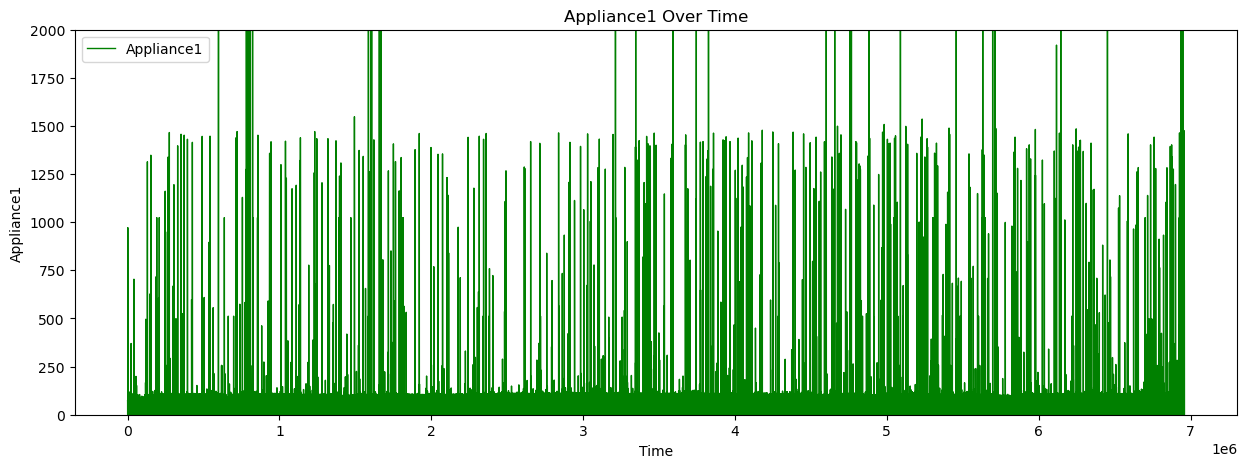

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance1'], label='Appliance1', color='green', linewidth=1)
#1.Fridge
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance1')
plt.title('Appliance1 Over Time')
plt.legend()
plt.show()


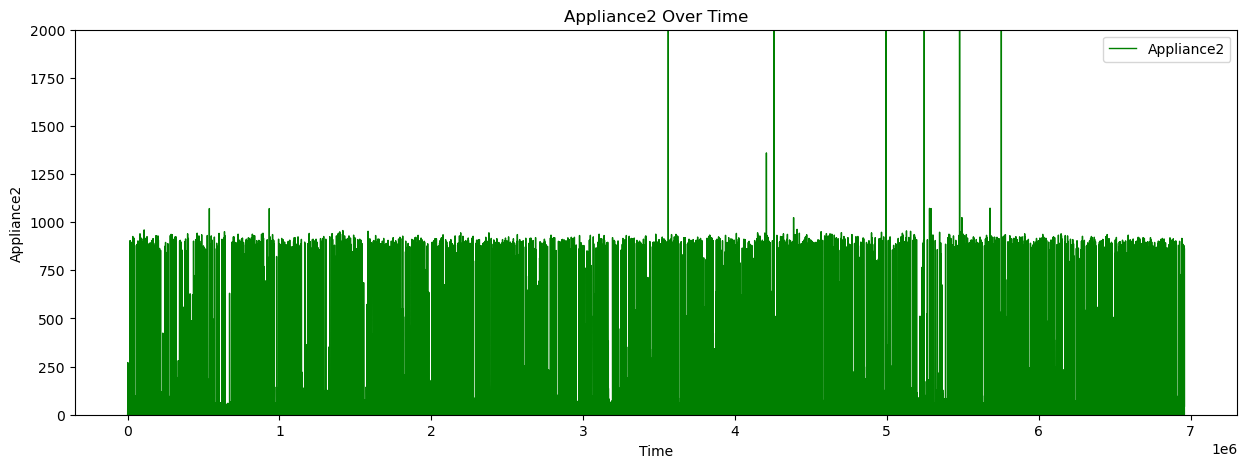

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance2'], label='Appliance2', color='green', linewidth=1)
#2.Chest Freezer,
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance2')
plt.title('Appliance2 Over Time')
plt.legend()
plt.show()


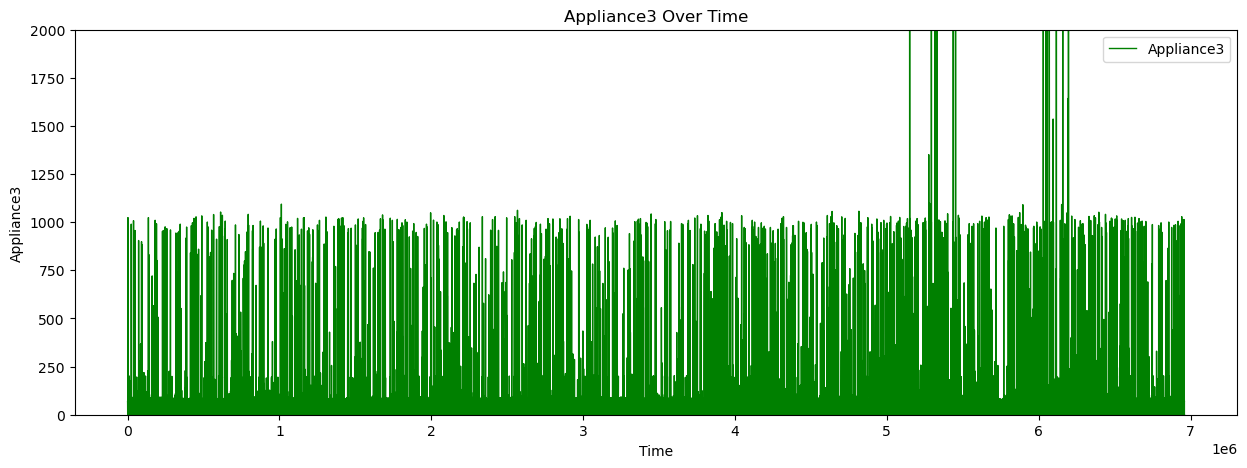

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance3'], label='Appliance3', color='green', linewidth=1)
#3.Upright Freezer
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance3')
plt.title('Appliance3 Over Time')
plt.legend()
plt.show()


D:\conda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


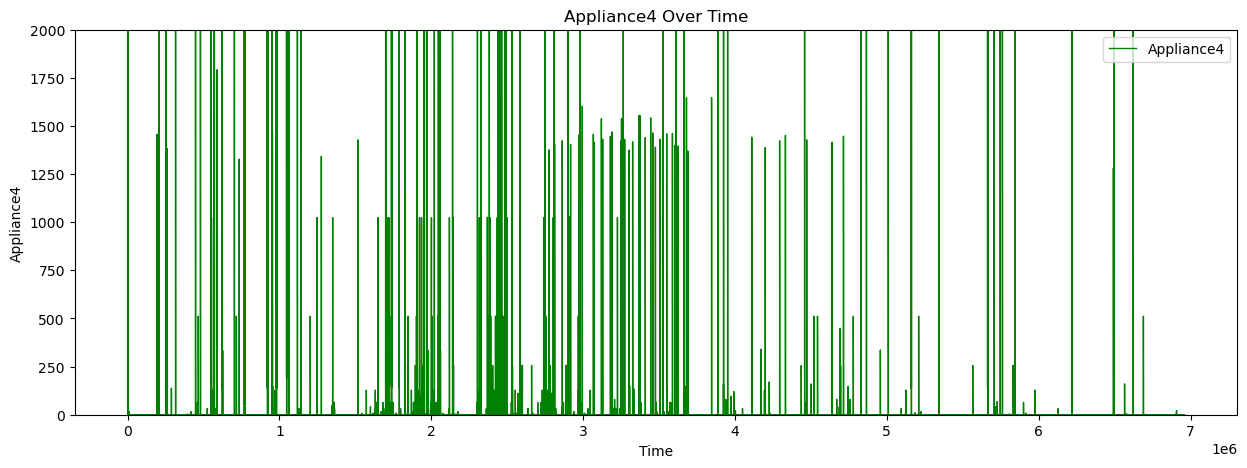

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance4'], label='Appliance4', color='green', linewidth=1)
#4.Tumble Dryer,
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance4')
plt.title('Appliance4 Over Time')
plt.legend()
plt.show()


D:\conda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


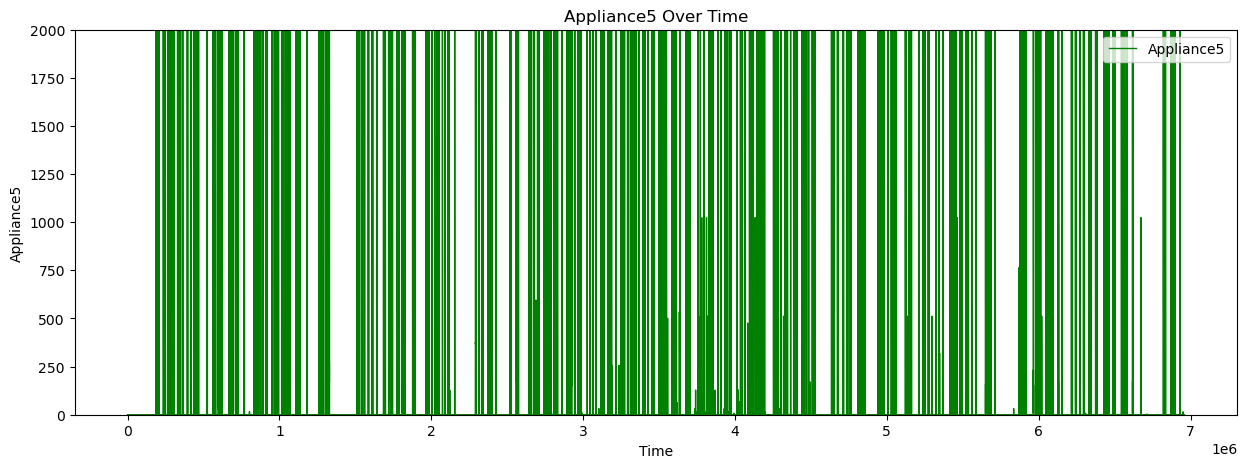

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance5'], label='Appliance5', color='green', linewidth=1)
5.Washing Machine
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance5')
plt.title('Appliance5 Over Time')
plt.legend()
plt.show()


D:\conda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


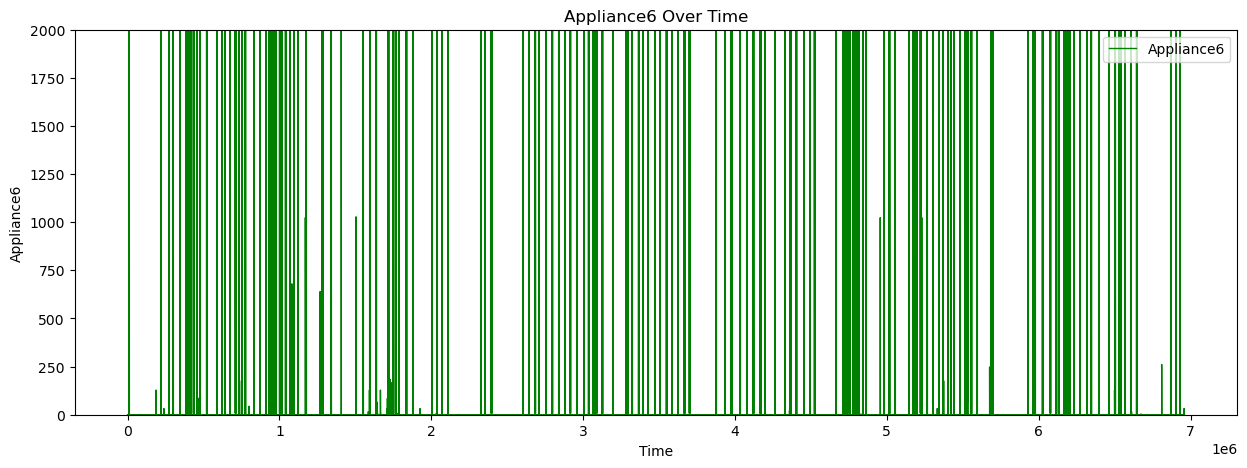

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance6'], label='Appliance6', color='green', linewidth=1)
#6.Dishwasher
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance6')
plt.title('Appliance6 Over Time')
plt.legend()
plt.show()


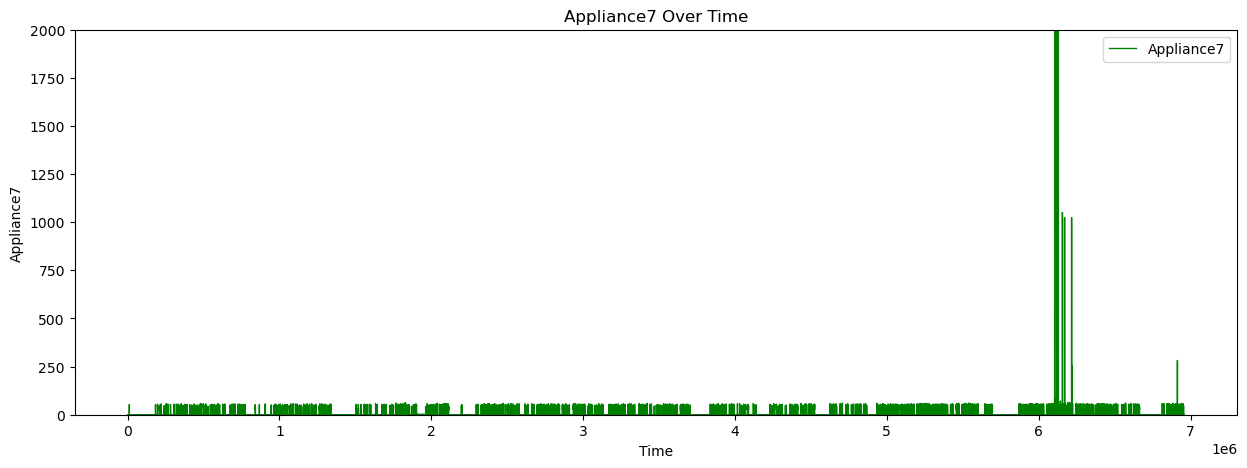

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance7'], label='Appliance7', color='green', linewidth=1)
#7.Computer Site
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance7')
plt.title('Appliance7 Over Time')
plt.legend()
plt.show()


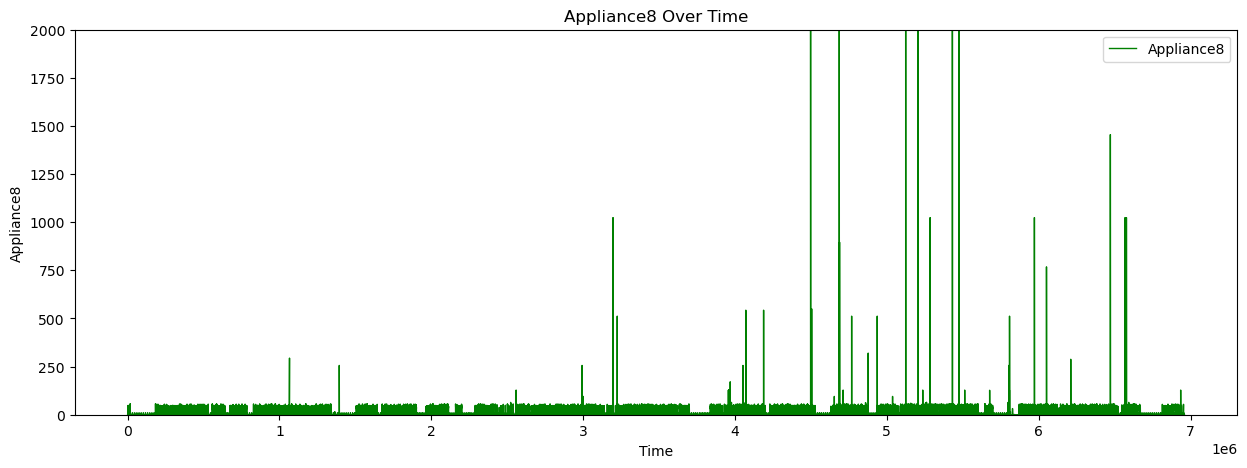

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance8'], label='Appliance8', color='green', linewidth=1)
#8.Television Site
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance8')
plt.title('Appliance8 Over Time')
plt.legend()
plt.show()


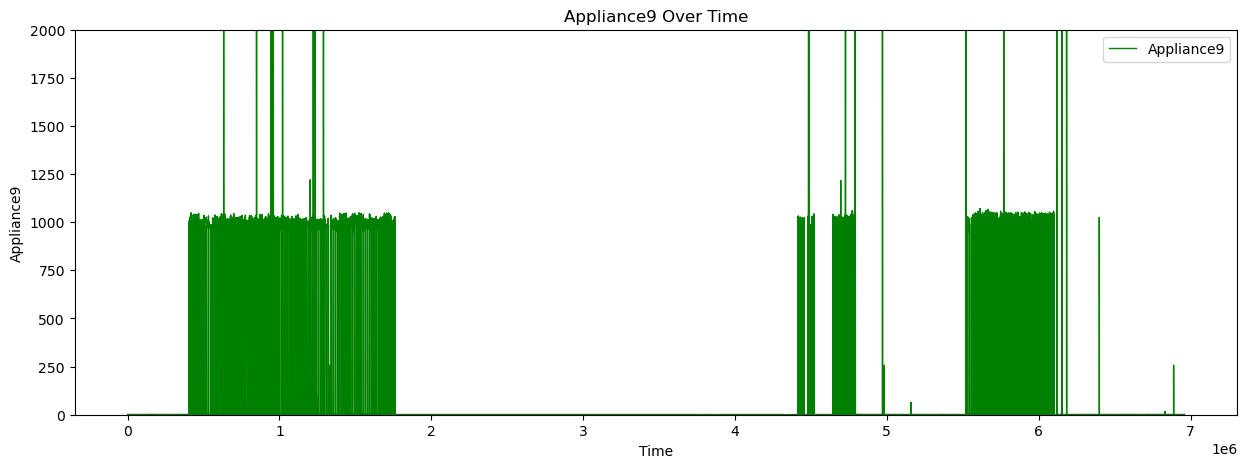

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("D:\\House_1.csv")

# Assuming your DataFrame is named 'df' and 'Time' is the datetime column
# If 'Time' is not set as the index, you can use df.set_index('Time', inplace=True)

# Plot time series for the aggregated load with adjusted y-axis limits
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliance9'], label='Appliance9', color='green', linewidth=1)
#9.Electric Heater
# Adjust the y-axis limits
plt.ylim(0, 2000)  # Adjust the upper limit as needed

plt.xlabel('Time')
plt.ylabel('Appliance9')
plt.title('Appliance9 Over Time')
plt.legend()
plt.show()


In [58]:
import pandas as pd

# Assuming you have a DataFrame named 'df' with a datetime index
# Replace 'YourColumn' with the actual column name in your dataset
your_column_name = 'Aggregate'

# Specify the window size for the moving average
window_size = 3  # You can adjust this based on your requirements

# Calculate the Simple Moving Average
df['SMA'] = df[your_column_name].rolling(window=window_size).mean()

# Drop rows with NaN values introduced by the rolling mean calculation
df.dropna(inplace=True)

# Print or visualize the original and smoothed data
print(df[[your_column_name, 'SMA']])


                     Aggregate         SMA
Time                                      
2013-10-09 13:06:46        540  529.666667
2013-10-09 13:07:01        532  532.666667
2013-10-09 13:07:15        540  537.333333
2013-10-09 13:07:18        539  537.000000
2013-10-09 13:07:30        537  538.666667
...                        ...         ...
2015-07-10 11:56:05        187  183.000000
2015-07-10 11:56:12        185  184.000000
2015-07-10 11:56:18        181  184.333333
2015-07-10 11:56:25        186  184.000000
2015-07-10 11:56:32        182  183.000000

[6960006 rows x 2 columns]


In [59]:
import pandas as pd

# Assuming you have a DataFrame named 'df' with a column named 'Aggregate' and a 'Time' index
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset
# You may also need to adjust the span parameter based on your data characteristics

# Calculate EMA with a specified span (adjust span as needed)
df['EMA'] = df['Aggregate'].ewm(span=10, adjust=False).mean()

# Display the DataFrame with the EMA column
print(df.head())


                           Unix  Aggregate  Appliance1  Appliance2  \
Time                                                                 
2013-10-09 13:06:46  1381324006        540          74           0   
2013-10-09 13:07:01  1381324021        532          74           0   
2013-10-09 13:07:15  1381324035        540          74           0   
2013-10-09 13:07:18  1381324038        539          74           0   
2013-10-09 13:07:30  1381324050        537          74           0   

                     Appliance3  Appliance4  Appliance5  Appliance6  \
Time                                                                  
2013-10-09 13:06:46          68           0           0           0   
2013-10-09 13:07:01          68           0           0           0   
2013-10-09 13:07:15          69           0           0           0   
2013-10-09 13:07:18          69           0           0           0   
2013-10-09 13:07:30          69           0           0           0   

           

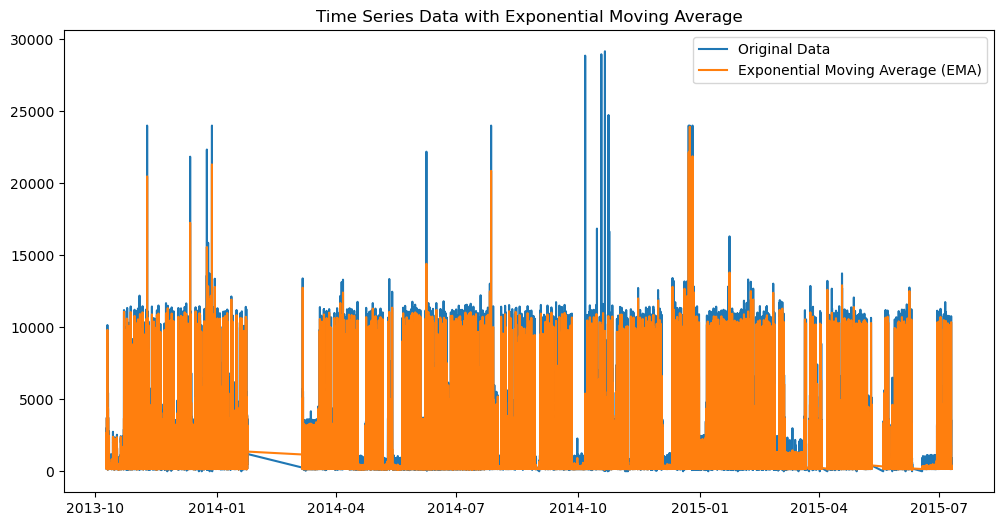

MemoryError: Unable to allocate 10.2 GiB for an array with shape (6960200, 196) and data type float64

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Assuming you have a DataFrame named 'df' with a column named 'Aggregate' and a 'Time' index
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset

# Plot the time series data
plt.figure(figsize=(12, 6))
plt.plot(df['Aggregate'], label='Original Data')
plt.plot(df['EMA'], label='Exponential Moving Average (EMA)')
plt.title('Time Series Data with Exponential Moving Average')
plt.legend()
plt.show()

# ADF Test for stationarity
result_adf = adfuller(df['Aggregate'], autolag='AIC')

# Extract and print the p-value
p_value_adf = result_adf[1]
print(f'ADF Test p-value: {p_value_adf}')

# Check the p-value against the significance level (e.g., 0.05)
if p_value_adf <= 0.05:
    print('The time series data is likely stationary.')
else:
    print('The time series data is likely non-stationary.')


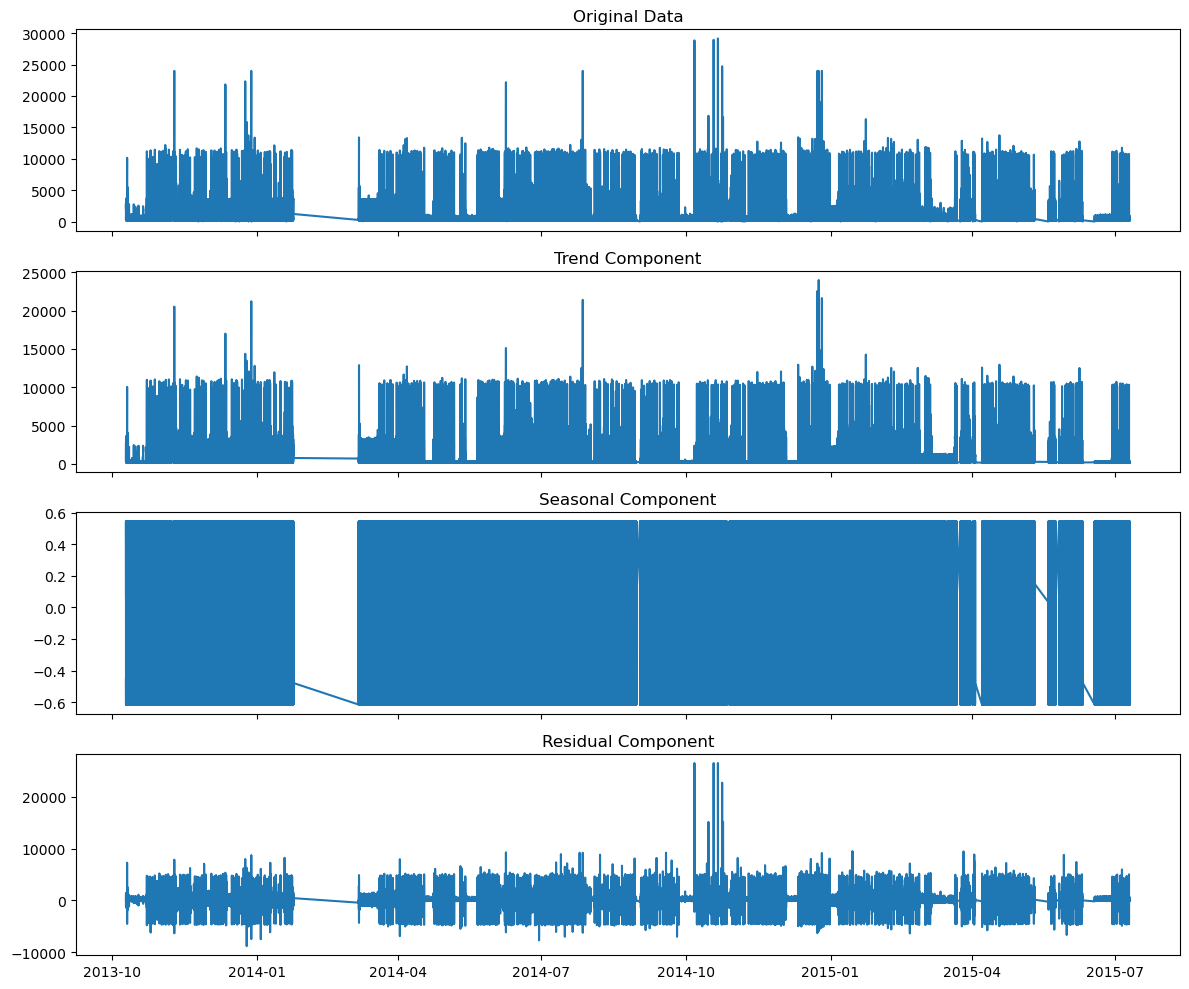

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming you have a DataFrame named 'df' with a column named 'Aggregate' and a 'Time' index
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset

# Perform seasonal decomposition
result = seasonal_decompose(df['Aggregate'], period=13)  # You may need to adjust the period parameter

# Plot the decomposition components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

ax1.plot(df['Aggregate'], label='Original Data')
ax1.set_title('Original Data')

ax2.plot(result.trend, label='Trend')
ax2.set_title('Trend Component')

ax3.plot(result.seasonal, label='Seasonal')
ax3.set_title('Seasonal Component')

ax4.plot(result.resid, label='Residual')
ax4.set_title('Residual Component')

plt.tight_layout()
plt.show()


ADF Test p-value: 0.0
Critical Values: {'1%': -3.430444033235823, '5%': -2.8615815610164606, '10%': -2.566792121509686}
The time series data is likely stationary based on the p-value.
The ADF statistic is lower than the critical value at 1%. The data is likely stationary.
The ADF statistic is lower than the critical value at 5%. The data is likely stationary.
The ADF statistic is lower than the critical value at 10%. The data is likely stationary.


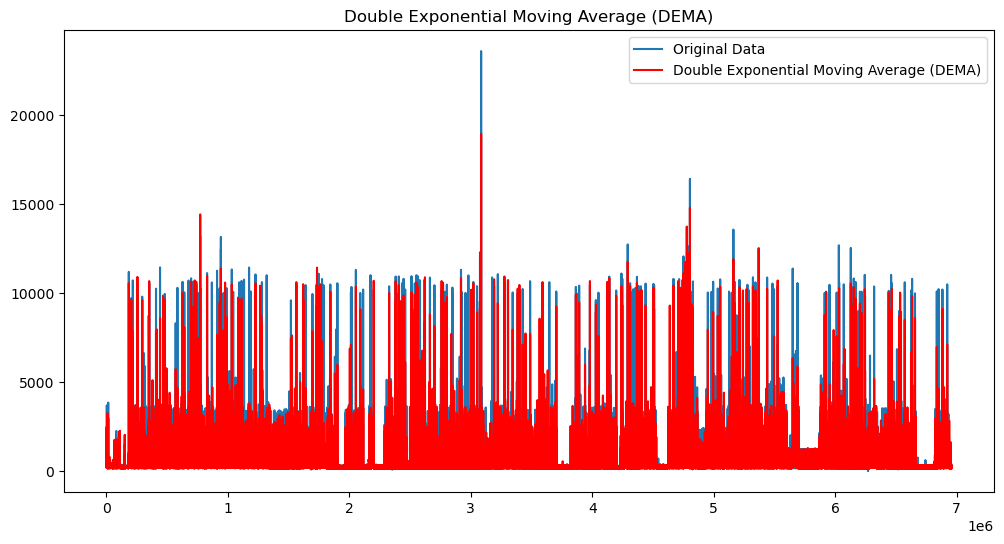

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# Read the CSV file into a DataFrame
df = pd.read_csv("D:\\House_1.csv")

# Define the smoothing constants (alpha and beta)
alpha = 0.2  # You can adjust these values based on your data
beta = 0.2

# Calculate the first-level smoothed series (EMA)
df['EMA'] = df['Aggregate'].ewm(alpha=alpha, adjust=False).mean()

# Calculate the second-level smoothed series (DEMA)
df['DEMA'] = df['EMA'].ewm(alpha=beta, adjust=False).mean()

# Sample every N points for analysis
N = 100
subset_df = df.iloc[::N]

# Perform ADF test on the subset
result = adfuller(subset_df['DEMA'], autolag='AIC')

# Extract and print the p-value and critical values
p_value = result[1]
critical_values = result[4]

print(f'ADF Test p-value: {p_value}')
print(f'Critical Values: {critical_values}')

# Check the p-value against the significance level (e.g., 0.05)
if p_value <= 0.05:
    print('The time series data is likely stationary based on the p-value.')
else:
    print('The time series data is likely non-stationary based on the p-value.')

# Check the critical values
for key, value in critical_values.items():
    if result[0] < value:
        print(f'The ADF statistic is lower than the critical value at {key}. The data is likely stationary.')
    else:
        print(f'The ADF statistic is higher than the critical value at {key}. The data is likely non-stationary.')

# Plot the original data and the DEMA
plt.figure(figsize=(12, 6))
plt.plot(subset_df['Aggregate'], label='Original Data')
plt.plot(subset_df['DEMA'], label='Double Exponential Moving Average (DEMA)', color='red')
plt.title('Double Exponential Moving Average (DEMA)')
plt.legend()
plt.show()


In [10]:
from statsmodels.tsa.stattools import adfuller

# Assuming you have a DataFrame named 'df' with a column named 'DEMA'
# Replace 'YourDataFrame' and 'YourColumnName' with the actual names in your dataset
x = 5
# Perform ADF test

result = adfuller(df['DEMA'], autolag='AIC')


# Extract and print the p-value and critical values
p_value = result[1]
critical_values = result[4]

print(f'ADF Test p-value: {p_value}')
print(f'Critical Values: {critical_values}')

# Check the p-value against the significance level (e.g., 0.05)
if p_value <= 0.05:
    print('The time series data is likely stationary based on the p-value.')
else:
    print('The time series data is likely non-stationary based on the p-value.')

# Check the critical values
for key, value in critical_values.items():
    if result[0] < value:
        print(f'The ADF statistic is lower than the critical value at {key}. The data is likely stationary.')
    else:
        print(f'The ADF statistic is higher than the critical value at {key}. The data is likely non-stationary.')


MemoryError: Unable to allocate 10.2 GiB for an array with shape (6960202, 196) and data type float64

7
